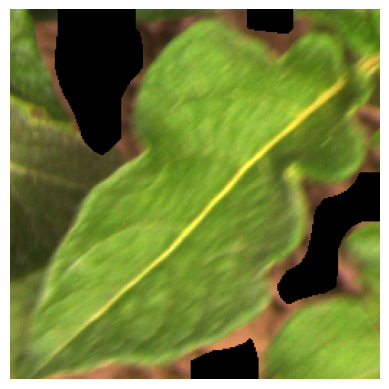

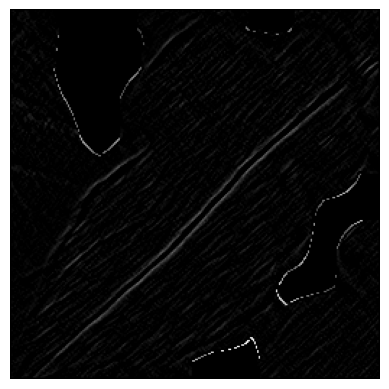

In [33]:
import matplotlib.pyplot as plt
import cv2
img = cv2.imread('Croptimal/resnet/train/256_class_0/6764beec-de30-41fd-ac4d-374023ed0a03_63.png')
sobel = cv2.imread('Croptimal/resnet/train/sobel_class_0/6764beec-de30-41fd-ac4d-374023ed0a03_63.png', cv2.IMREAD_GRAYSCALE)
# fig, ax = plt.subplots(1, 2, figsize=(6, 3))
plt.axis('off')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(sobel, cmap='gray')
plt.axis('off')
plt.show()
# ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
# ax[0].set_title("Original Image")
# ax[0].axis('off')
# ax[1].imshow(sobel, cmap='gray')
# ax[1].set_title("Sobel Image")
# ax[1].axis('off')

Processing 27bb6d3d-77c3-486b-a22a-3741dde393ee_40.png (1/2258)
Saving Sobel image to Croptimal/resnet/train/sobel_class_0/27bb6d3d-77c3-486b-a22a-3741dde393ee_40.png
Processing 00367bac-0715-41b8-93dd-c21b8877a1f3_73.png (1/1390)
Saving Sobel image to Croptimal/resnet/train/sobel_class_1/00367bac-0715-41b8-93dd-c21b8877a1f3_73.png
Processing a9e37804-c00a-4e4e-b99f-e267a0056a05_80.png (1/458)
Saving Sobel image to Croptimal/resnet/val/sobel_class_0/a9e37804-c00a-4e4e-b99f-e267a0056a05_80.png
Processing 5dd583fd-676a-4bca-b839-fb3bbf118e8c_117.png (1/288)
Saving Sobel image to Croptimal/resnet/val/sobel_class_1/5dd583fd-676a-4bca-b839-fb3bbf118e8c_117.png


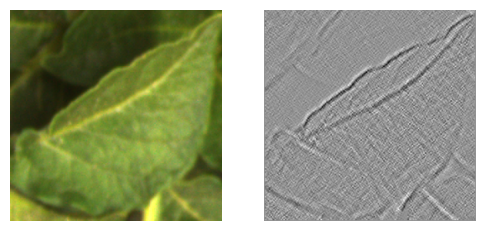

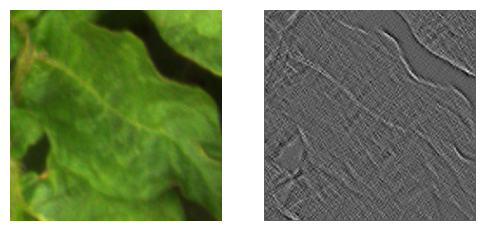

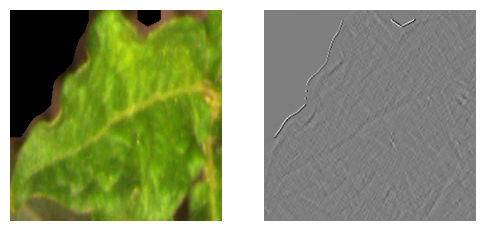

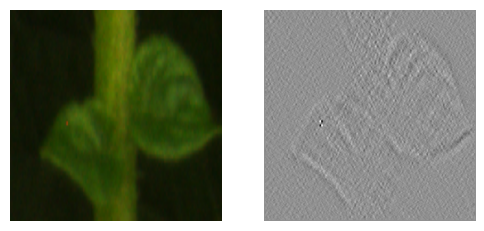

In [29]:
import torch
import sys
from pathlib import Path
sys.path.insert(0, 'LVQ')
sys.path.insert(0, 'LVQ/plant-segmentation')
import alvq
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

ds = 24           # downscale factor for probability smoothing
p_threshold = 0.3 # (average) probability threshold

PLOT = True

directories = [Path("Croptimal/resnet/train/256_class_0"), Path("Croptimal/resnet/train/256_class_1"), Path("Croptimal/resnet/val/256_class_0"), Path("Croptimal/resnet/val/256_class_1")]
for directory in directories:
    for count, file_path in enumerate(directory.glob("*.png")):
        print(f"Processing {file_path.name} ({count + 1}/{len(list(directory.glob('*.png')))})")
        img = cv2.imread(str(file_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        sobel = cv2.Sobel(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), cv2.CV_64F, 1, 1, ksize=3)
        if PLOT:
            fig, ax = plt.subplots(1, 2, figsize=(6, 3))
            ax[0].imshow(img)
            ax[1].imshow(sobel, cmap='gray')
            ax[0].axis('off')
            ax[1].axis('off')
        savepath = file_path.parent.parent / f"sobel{file_path.parent.stem[3:]}" / file_path.name
        print(f"Saving Sobel image to {savepath}")
        os.makedirs(savepath.parent, exist_ok=True)
        cv2.imwrite(str(savepath), sobel)
        break